In [93]:
import numpy as np
import itertools
import matplotlib.pyplot as plt 
from matplotlib.patches import Patch
import time


In [94]:
# -------------------------
# 1) Tous les subsets non vides
# -------------------------
def all_subsets(p):
    subsets = []
    for k in range(1, p+1):
        subsets += list(itertools.combinations(range(p), k))
    return subsets

# -------------------------
# 2) Tirage uniforme de U
# -------------------------
def sample_U(subsets):
    idx = np.random.randint(len(subsets))
    return subsets[idx], idx

# -------------------------
# 3) Pick-Freeze
# -------------------------
def pick_freeze(X, Xp, U):
    XU = Xp.copy()
    for i in U:
        XU[i] = X[i]
    return XU

# -------------------------
# 4) Calcul M^{-1}s pour un subset U
# = somme des s_v pour v ⊆ U
# -------------------------
def Minv_s(s, subsets, U):
    total = 0
    for j, v in enumerate(subsets):
        if set(v).issubset(U):
            total += s[j]
    return total

# -------------------------
# 5) Gradient
# -------------------------
def gradient(s, subsets, U, Y, YU, m):
    q = len(s)
    g = np.zeros(q)
    
    a = Y - m
    Minv = Minv_s(s, subsets, U)
    scalar = a * Minv - (YU - m)
    
    for j, v in enumerate(subsets):
        if set(v).issubset(U):
            g[j] = a * scalar
            
    return g

# -------------------------
# 6) Mirror update
# -------------------------
def mirror_update(s, g, eta):
    s_new = s * np.exp(-eta * g)
    return s_new / np.sum(s_new)

# -------------------------
# 7) Algorithme principal
# -------------------------
def run_algorithm(f, p, N, sample_X, eta0=0.3):
    
    subsets = all_subsets(p)
    q = len(subsets)
    
    # Initialisation uniforme
    s = np.ones(q) / q
    m = 0
    
    for n in range(N):
        
        eta = eta0 / np.sqrt(n+1)
        
        # --- Distribution choisie ---
        X = sample_X(p)
        Xp = sample_X(p)
        
        # Sample subset
        U, idxU = sample_U(subsets)
        
        # Pick-Freeze
        Y = f(X)
        XU = pick_freeze(X, Xp, U)
        YU = f(XU)
        
        g = gradient(s, subsets, set(U), Y, YU, m)
        s = mirror_update(s, g, eta)
        
        m = m + (Y - m) / (n+1)
    
    return s, subsets

def get_first_order(s, subsets, p):
    first = np.zeros(p)
    for j, U in enumerate(subsets):
        if len(U) == 1:
            i = U[0]
            first[i] = s[j]
    return first

def get_total_order(s, subsets, p):
    total = np.zeros(p)
    for j, U in enumerate(subsets):
        for i in U:
            total[i] += s[j]
    return total

In [95]:
def sobol_pf_first_order(f, p, N, sample_X):
    Y_vals = np.zeros(N)
    Y_freeze = np.zeros((p, N))
    
    for n in range(N):
        X = sample_X(p)
        Xp = sample_X(p)
        
        Y = f(X)
        Y_vals[n] = Y
        
        for i in range(p):
            XU = Xp.copy()
            XU[i] = X[i]   # freeze variable i
            Y_freeze[i, n] = f(XU)
    
    VarY = np.var(Y_vals, ddof=1)
    
    S = np.zeros(p)
    for i in range(p):
        cov = np.cov(Y_vals, Y_freeze[i], ddof=1)[0,1]
        S[i] = cov / VarY
        
    return S

def sobol_pf_total_order(f, p, N, sample_X):
    Y_vals = np.zeros(N)
    Y_freeze = np.zeros((p, N))
    
    for n in range(N):
        X = sample_X(p)
        Xp = sample_X(p)
        
        Y = f(X)
        Y_vals[n] = Y
        
        for i in range(p):
            XU = X.copy()
            XU[i] = Xp[i]   # replace variable i
            Y_freeze[i, n] = f(XU)
    
    VarY = np.var(Y_vals, ddof=1)
    
    ST = np.zeros(p)
    for i in range(p):
        ST[i] = np.mean((Y_vals - Y_freeze[i])**2) / (2 * VarY)
        
    return ST



C:\Users\achle\AppData\Local\Temp\ipykernel_24756\2896681946.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(first_results, labels=[f"X{i+1}" for i in range(p)])


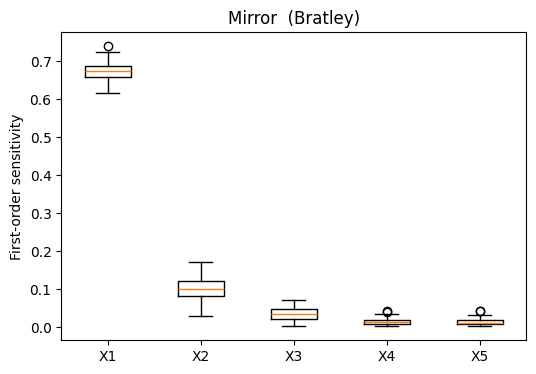

C:\Users\achle\AppData\Local\Temp\ipykernel_24756\2896681946.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(total_results, labels=[f"X{i+1}" for i in range(p)])


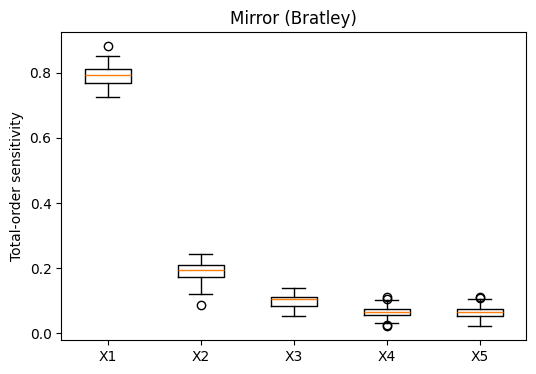

In [96]:
def f_bratley(x):
    s = 0
    prod = 1
    for i in range(len(x)):
        prod *= x[i]
        s += (-1)**(i+1) * prod
    return s


p = 5
N = 5000
MC = 50

def sample_uniform(p):
    return np.random.rand(p)

first_results = []
total_results = []

start = time.time()
for _ in range(MC):
    
    s_hat, subsets = run_algorithm(
        f_bratley,
        p,
        N,
        sample_X=sample_uniform, eta0=10.0
    )
    
    first = get_first_order(s_hat, subsets, p)
    total = get_total_order(s_hat, subsets, p)
    
    first_results.append(first)
    total_results.append(total)
mirror_time = time.time() - start
first_results = np.array(first_results)
total_results = np.array(total_results)


first_pf = []
total_pf = []

start = time.time()
for _ in range(MC):
    first = sobol_pf_first_order(f_bratley, p, N, sample_uniform)
    total = sobol_pf_total_order(f_bratley, p, N, sample_uniform)
    
    first_pf.append(first)
    total_pf.append(total)

pf_time = time.time() - start
first_pf = np.array(first_pf)
total_pf = np.array(total_pf)


plt.figure(figsize=(6,4))
plt.boxplot(first_results, labels=[f"X{i+1}" for i in range(p)])
plt.ylabel("First-order sensitivity")
plt.title("Mirror  (Bratley)")
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(total_results, labels=[f"X{i+1}" for i in range(p)])
plt.ylabel("Total-order sensitivity")
plt.title("Mirror (Bratley)")
plt.show()


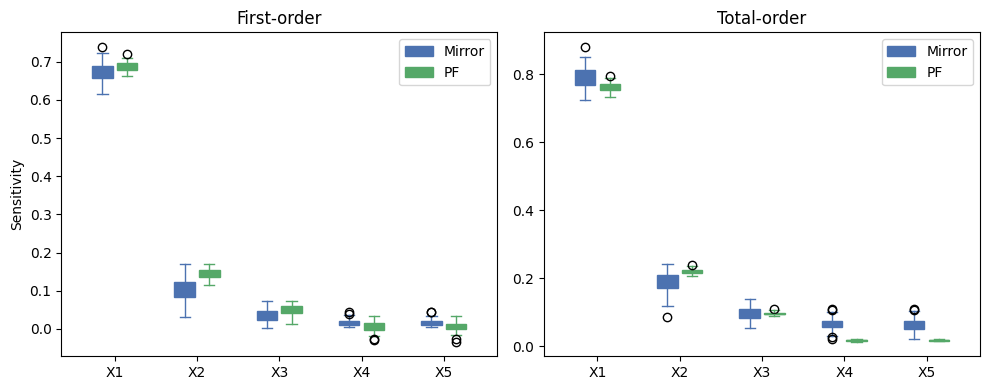


Total time over 50 runs:
Mirror: 5.76 s
PF: 5.17 s
Speed ratio PF / Mirror = 0.90
First-order means
X1  Mirror=0.6722  PF=0.6876
X2  Mirror=0.1004  PF=0.1443
X3  Mirror=0.0351  PF=0.0498
X4  Mirror=0.0169  PF=0.0059
X5  Mirror=0.0163  PF=0.0060

Total-order means
X1  Mirror=0.7921  PF=0.7641
X2  Mirror=0.1894  PF=0.2205
X3  Mirror=0.0983  PF=0.0973
X4  Mirror=0.0654  PF=0.0178
X5  Mirror=0.0652  PF=0.0177


In [97]:
color_mirror = "#4C72B0"   # bleu
color_pf = "#55A868"       # vert

fig, axes = plt.subplots(1, 2, figsize=(10,4))
legend_elements = [
    Patch(facecolor=color_mirror, edgecolor=color_mirror, label='Mirror'),
    Patch(facecolor=color_pf, edgecolor=color_pf, label='PF')
]

# ======================
# FIRST-ORDER
# ======================
ax = axes[0]

for i in range(p):
    # Mirror
    bp1 = ax.boxplot(first_results[:, i],
                     positions=[i+1-0.15],
                     widths=0.25,
                     patch_artist=True)

    # PF
    bp2 = ax.boxplot(first_pf[:, i],
                     positions=[i+1+0.15],
                     widths=0.25,
                     patch_artist=True)

    # couleur Mirror
    for element in ['boxes','whiskers','caps','medians']:
        plt.setp(bp1[element], color=color_mirror)
    bp1['boxes'][0].set_facecolor(color_mirror)

    # couleur PF
    for element in ['boxes','whiskers','caps','medians']:
        plt.setp(bp2[element], color=color_pf)
    bp2['boxes'][0].set_facecolor(color_pf)

ax.set_xticks(range(1, p+1))
ax.set_xticklabels([f"X{i+1}" for i in range(p)])
axes[0].legend(handles=legend_elements, loc='upper right')
ax.set_title("First-order")
ax.set_ylabel("Sensitivity")

# ======================
# TOTAL-ORDER
# ======================
ax = axes[1]

for i in range(p):
    bp1 = ax.boxplot(total_results[:, i],
                     positions=[i+1-0.15],
                     widths=0.25,
                     patch_artist=True)

    bp2 = ax.boxplot(total_pf[:, i],
                     positions=[i+1+0.15],
                     widths=0.25,
                     patch_artist=True)

    for element in ['boxes','whiskers','caps','medians']:
        plt.setp(bp1[element], color=color_mirror)
    bp1['boxes'][0].set_facecolor(color_mirror)

    for element in ['boxes','whiskers','caps','medians']:
        plt.setp(bp2[element], color=color_pf)
    bp2['boxes'][0].set_facecolor(color_pf)

ax.set_xticks(range(1, p+1))
axes[1].legend(handles=legend_elements, loc='upper right')
ax.set_xticklabels([f"X{i+1}" for i in range(p)])
ax.set_title("Total-order")

plt.tight_layout()
plt.show()


print(f"\nTotal time over {MC} runs:")
print(f"Mirror: {mirror_time:.2f} s")
print(f"PF: {pf_time:.2f} s")
print(f"Speed ratio PF / Mirror = {pf_time/mirror_time:.2f}")

print("First-order means")
for i in range(p):
    print(f"X{i+1}  Mirror={first_results[:,i].mean():.4f}  PF={first_pf[:,i].mean():.4f}")

print("\nTotal-order means")
for i in range(p):
    print(f"X{i+1}  Mirror={total_results[:,i].mean():.4f}  PF={total_pf[:,i].mean():.4f}")
